
TRE STATISTICS (Mean ± Std Dev / Median in mm)

Full Sweep
--------------------------------------------------------------------------------

  Pose 1:
    L1:  1.768 ± 0.081 mm  (median: 1.777)  (n=30)
    L2:  1.475 ± 0.052 mm  (median: 1.477)  (n=30)
    L3:  1.201 ± 0.081 mm  (median: 1.211)  (n=30)
    L4:  0.908 ± 0.068 mm  (median: 0.916)  (n=30)

  Pose 2:
    L1:  1.193 ± 0.081 mm  (median: 1.190)  (n=30)
    L2:  1.408 ± 0.100 mm  (median: 1.427)  (n=30)
    L3:  1.156 ± 0.040 mm  (median: 1.145)  (n=30)
    L4:  1.106 ± 0.037 mm  (median: 1.111)  (n=30)

  OVERALL (all poses & vertebrae):  1.277 ± 0.257 mm  (median: 1.203)  (n=240)

Slice Sweep
--------------------------------------------------------------------------------

  Pose 1:
    L1:  1.755 ± 0.253 mm  (median: 1.724)  (n=30)
    L2:  1.366 ± 0.159 mm  (median: 1.318)  (n=30)
    L3:  0.998 ± 0.184 mm  (median: 0.997)  (n=30)
    L4:  0.951 ± 0.234 mm  (median: 0.906)  (n=30)

  Pose 2:
    L1:  2.074 ± 0.224 mm  (m

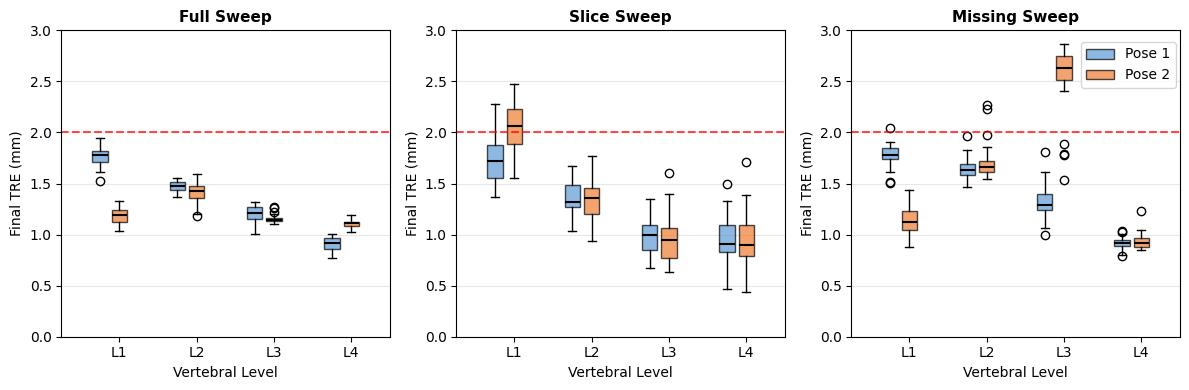

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from pathlib import Path

# Base path - UPDATE THIS to your actual path
BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"

# Define the structure
poses = ['sofa1', 'sofa3']  # Corresponds to Pose 1, 2, 3
conditions = ['full', 'slice', 'missing']
vertebrae = ['L1', 'L2', 'L3', 'L4']

def load_tre_data(filepath):
    """
    Load TRE data from JSON file.
    
    Expected return format:
    {
        'L1': [list of TRE values],
        'L2': [list of TRE values],
        'L3': [list of TRE values],
        'L4': [list of TRE values]
    }
    """
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        tre_by_vertebra = {'L1': [], 'L2': [], 'L3': [], 'L4': []}
        
        # Extract final_tre data from the first (and typically only) entry
        for key in data.keys():
            if key != '_summary' and 'final_tre' in data[key]:
                final_tre_list = data[key]['final_tre']
                
                # Collect TRE values for each vertebra across ALL runs
                for i, tre_dict in enumerate(final_tre_list):
                    for vert in ['L1', 'L2', 'L3', 'L4']:
                        tre_by_vertebra[vert].append(tre_dict[vert])
                
                break  # Assuming one main entry per file
        
        return tre_by_vertebra
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def collect_data():
    """Collect all TRE data organized by condition and initialization type."""
    data = {
        'full_normal': {},           # Panel 1: full/constraints.json
        'slice_normal': {},          # Panel 2: slice/constraints.json
        'missing_normal': {},        # Panel 3: missing/constraints.json
    }
    
    # Initialize data structure for each vertebra and pose
    for panel in data.keys():
        for vert in vertebrae:
            data[panel][vert] = {}
            for pose_idx in range(len(poses)):
                data[panel][vert][f'Pose {pose_idx + 1}'] = []
    
    for pose_idx, pose in enumerate(poses):
        pose_name = f'Pose {pose_idx + 1}'
        
        # Full sweep - normal
        full_normal_path = os.path.join(BASE_PATH, pose, 'full', '30', 'constraints.json')
        if os.path.exists(full_normal_path):
            full_normal_data = load_tre_data(full_normal_path)
            if full_normal_data:
                for vert in vertebrae:
                    if vert in full_normal_data and full_normal_data[vert]:
                        data['full_normal'][vert][pose_name] = full_normal_data[vert]
        else:
            print(f"Warning: File not found: {full_normal_path}")
        
        # Slice sweep - normal
        slice_normal_path = os.path.join(BASE_PATH, pose, 'slice','30', 'constraints.json')
        if os.path.exists(slice_normal_path):
            slice_normal_data = load_tre_data(slice_normal_path)
            if slice_normal_data:
                for vert in vertebrae:
                    if vert in slice_normal_data and slice_normal_data[vert]:
                        data['slice_normal'][vert][pose_name] = slice_normal_data[vert]
        else:
            print(f"Warning: File not found: {slice_normal_path}")
        
        # Missing sweep - normal
        missing_normal_path = os.path.join(BASE_PATH, pose, 'missing','30', 'constraints.json')
        if os.path.exists(missing_normal_path):
            missing_normal_data = load_tre_data(missing_normal_path)
            if missing_normal_data:
                for vert in vertebrae:
                    if vert in missing_normal_data and missing_normal_data[vert]:
                        data['missing_normal'][vert][pose_name] = missing_normal_data[vert]
        else:
            print(f"Warning: File not found: {missing_normal_path}")
    
    return data

def print_statistics(data):
    """Print mean, median, and standard deviation for each condition, pose, and vertebra."""
    print("\n" + "="*80)
    print("TRE STATISTICS (Mean ± Std Dev / Median in mm)")
    print("="*80)
    
    conditions = [
        ('full_normal', 'Full Sweep'),
        ('slice_normal', 'Slice Sweep'),
        ('missing_normal', 'Missing Sweep')
    ]
    
    # Store overall values for summary
    overall_summary = {}
    
    for condition_key, title in conditions:
        print(f"\n{title}")
        print("-" * 80)
        
        # Collect all values for overall statistics
        all_values = []
        
        for pose_idx in range(len(poses)):
            pose_name = f'Pose {pose_idx + 1}'
            print(f"\n  {pose_name}:")
            
            for vert in vertebrae:
                if vert in data[condition_key] and pose_name in data[condition_key][vert]:
                    values = data[condition_key][vert][pose_name]
                    if len(values) > 0:
                        mean_val = np.mean(values)
                        median_val = np.median(values)
                        std_val = np.std(values)
                        n = len(values)
                        print(f"    {vert}:  {mean_val:.3f} ± {std_val:.3f} mm  (median: {median_val:.3f})  (n={n})")
                        all_values.extend(values)
                    else:
                        print(f"    {vert}:  No data available")
                else:
                    print(f"    {vert}:  No data available")
        
        # Print overall statistics for this condition
        if len(all_values) > 0:
            overall_mean = np.mean(all_values)
            overall_median = np.median(all_values)
            overall_std = np.std(all_values)
            overall_n = len(all_values)
            print(f"\n  OVERALL (all poses & vertebrae):  {overall_mean:.3f} ± {overall_std:.3f} mm  (median: {overall_median:.3f})  (n={overall_n})")
            overall_summary[title] = (overall_mean, overall_median, overall_std, overall_n)
        else:
            print(f"\n  OVERALL:  No data available")
            overall_summary[title] = None
    
    # Print summary comparison
    print("\n" + "="*80)
    print("SUMMARY: Overall Mean TRE Across All Levels and Poses")
    print("="*80)
    for title in ['Full Sweep', 'Slice Sweep', 'Missing Sweep']:
        if overall_summary.get(title):
            mean, median, std, n = overall_summary[title]
            print(f"{title:20s}:  {mean:.3f} ± {std:.3f} mm  (median: {median:.3f})  (n={n})")
        else:
            print(f"{title:20s}:  No data available")
    print("="*80 + "\n")

def create_boxplot(ax, data_dict, title, vertebrae_labels):
    """Create a single subplot with box plots."""
    colors = ['#5B9BD5', '#ED7D31']  # Blue, Orange, Green for Pose 1, 2, 3
    
    positions_base = np.arange(len(vertebrae_labels))
    width = 0.25
    
    all_boxes = []
    
    for pose_idx in range(len(poses)):
        pose_name = f'Pose {pose_idx + 1}'
        positions = positions_base + (pose_idx - 1) * width
        
        # Collect data for each vertebra
        plot_data = []
        for vert in vertebrae_labels:
            if vert in data_dict and pose_name in data_dict[vert]:
                plot_data.append(data_dict[vert][pose_name])
            else:
                plot_data.append([])  # Empty if no data
        
        # Create box plot
        bp = ax.boxplot(plot_data, positions=positions, widths=width*0.8,
                       patch_artist=True, showfliers=True,
                       boxprops=dict(facecolor=colors[pose_idx], alpha=0.7),
                       medianprops=dict(color='black', linewidth=1.5),
                       whiskerprops=dict(color='black'),
                       capprops=dict(color='black'))
        
        all_boxes.append(bp['boxes'][0])
    
    # Add reference line at 2.0 mm
    ax.axhline(y=2.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Formatting
    ax.set_xticks(positions_base)
    ax.set_xticklabels(vertebrae_labels)
    ax.set_xlabel('Vertebral Level', fontsize=10)
    ax.set_ylabel('Final TRE (mm)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 3) 
    ax.grid(True, alpha=0.3, axis='y')
    
    return all_boxes

def main():
    # Collect all data
    print("Collecting data...")
    data = collect_data()
    
    # Print statistics
    print_statistics(data)
    
    # Create figure with 1x3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # Plot each condition with normal initialization
    boxes1 = create_boxplot(axes[0], data['full_normal'], 
                           'Full Sweep', vertebrae)
    boxes2 = create_boxplot(axes[1], data['slice_normal'], 
                           'Slice Sweep', vertebrae)
    boxes3 = create_boxplot(axes[2], data['missing_normal'], 
                           'Missing Sweep', vertebrae)
    
    # Add legend
    pose_labels = ['Pose 1', 'Pose 2']
    colors = ['#5B9BD5', '#ED7D31', '#70AD47']
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[i], alpha=0.7, 
                                    edgecolor='black', label=pose_labels[i]) 
                      for i in range(2)]
    
    fig.legend(handles=legend_elements, loc='upper right', 
              bbox_to_anchor=(0.99, 0.9), frameon=True)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


TRE STATISTICS (Mean ± Std Dev / Median in mm)

Full Sweep + Rand Init
--------------------------------------------------------------------------------

  Pose 1:
    With Constraints:    1.234 ± 0.053 mm  (median: 1.223)  (n=10)
    No Constraints:      2.465 ± 1.001 mm  (median: 2.158)  (n=10)

  Pose 2:
    With Constraints:    1.225 ± 0.075 mm  (median: 1.224)  (n=10)
    No Constraints:      2.019 ± 0.819 mm  (median: 1.675)  (n=10)

  OVERALL (all poses):
    With Constraints:    1.229 ± 0.065 mm  (median: 1.224)  (n=20)
    No Constraints:      2.242 ± 0.941 mm  (median: 1.866)  (n=20)

Slice Sweep + Rand Init
--------------------------------------------------------------------------------

  Pose 1:
    With Constraints:    1.290 ± 0.099 mm  (median: 1.279)  (n=10)
    No Constraints:      6.092 ± 5.957 mm  (median: 3.904)  (n=10)

  Pose 2:
    With Constraints:    1.354 ± 0.106 mm  (median: 1.313)  (n=10)
    No Constraints:      8.600 ± 8.569 mm  (median: 3.662)  (n=10)

  

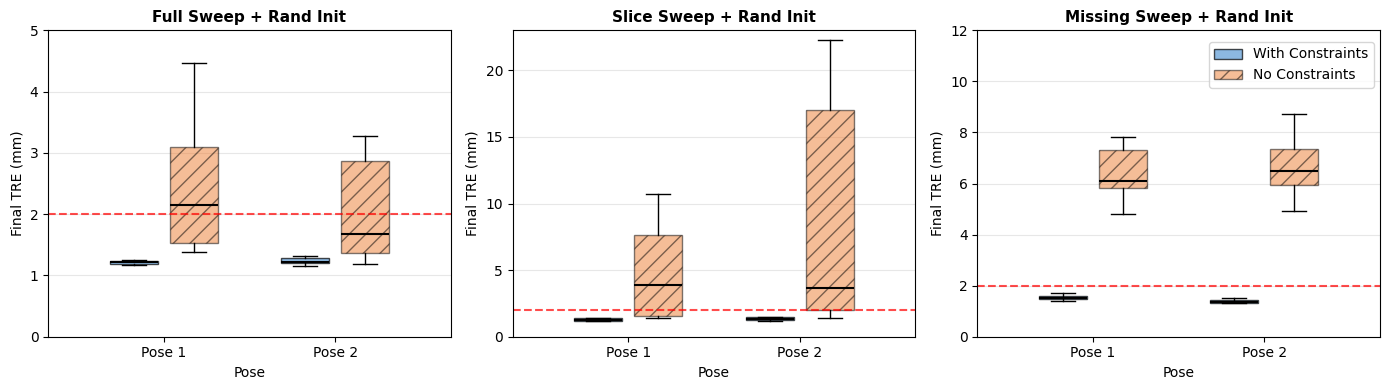

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from pathlib import Path

# Base path - UPDATE THIS to your actual path
BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"

# Define the structure
poses = ['sofa1', 'sofa3']  # Corresponds to Pose 1, 2, 3
conditions = ['full', 'slice', 'missing']
vertebrae = ['L1', 'L2', 'L3', 'L4']

def load_tre_data(filepath):
    """
    Load TRE data from JSON file and return mean across vertebrae for each run.
    
    Expected return format:
    [list of mean TRE values across all vertebrae for each run]
    """
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        mean_tre_list = []
        
        # Extract final_tre data from the first (and typically only) entry
        for key in data.keys():
            if key != '_summary' and 'final_tre' in data[key]:
                final_tre_list = data[key]['final_tre']
                
                # For each run, calculate mean TRE across all vertebrae
                for i, tre_dict in enumerate(final_tre_list):
                    vertebra_values = [tre_dict[vert] for vert in vertebrae]
                    mean_tre = np.mean(vertebra_values)
                    mean_tre_list.append(mean_tre)
                
                break  # Assuming one main entry per file
        
        return mean_tre_list
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def collect_data():
    """Collect all TRE data organized by condition and pose."""
    data = {
        'full_rand': {},             # Panel 1: full/robust_constraints.json
        'slice_rand': {},            # Panel 2: slice/robust_constraints.json
        'missing_rand': {},          # Panel 3: missing/robust_constraints.json
        'full_no_constraints': {},   # Panel 1: full/robust_no_constraints.json
        'slice_no_constraints': {},  # Panel 2: slice/robust_no_constraints.json
        'missing_no_constraints': {} # Panel 3: missing/robust_no_constraints.json
    }
    
    # Initialize data structure for each pose
    for panel in data.keys():
        for pose_idx in range(len(poses)):
            data[panel][f'Pose {pose_idx + 1}'] = []
    
    for pose_idx, pose in enumerate(poses):
        pose_name = f'Pose {pose_idx + 1}'
        
        # Full sweep - random init
        full_rand_path = os.path.join(BASE_PATH, pose, 'full', 'robust_constraints.json')
        if os.path.exists(full_rand_path):
            full_rand_data = load_tre_data(full_rand_path)
            if full_rand_data:
                data['full_rand'][pose_name] = full_rand_data
        else:
            print(f"Warning: File not found: {full_rand_path}")
        
        # Full sweep - no constraints
        full_no_constraints_path = os.path.join(BASE_PATH, pose, 'full', 'robust_no_constraints.json')
        if os.path.exists(full_no_constraints_path):
            full_no_constraints_data = load_tre_data(full_no_constraints_path)
            if full_no_constraints_data:
                data['full_no_constraints'][pose_name] = full_no_constraints_data
        else:
            print(f"Warning: File not found: {full_no_constraints_path}")
        
        # Slice sweep - random init
        slice_rand_path = os.path.join(BASE_PATH, pose, 'slice', 'robust_constraints.json')
        if os.path.exists(slice_rand_path):
            slice_rand_data = load_tre_data(slice_rand_path)
            if slice_rand_data:
                data['slice_rand'][pose_name] = slice_rand_data
        else:
            print(f"Warning: File not found: {slice_rand_path}")
        
        # Slice sweep - no constraints
        slice_no_constraints_path = os.path.join(BASE_PATH, pose, 'slice', 'robust_no_constraints.json')
        if os.path.exists(slice_no_constraints_path):
            slice_no_constraints_data = load_tre_data(slice_no_constraints_path)
            if slice_no_constraints_data:
                data['slice_no_constraints'][pose_name] = slice_no_constraints_data
        else:
            print(f"Warning: File not found: {slice_no_constraints_path}")
        
        # Missing sweep - random init
        missing_rand_path = os.path.join(BASE_PATH, pose, 'missing', 'robust_constraints.json')
        if os.path.exists(missing_rand_path):
            missing_rand_data = load_tre_data(missing_rand_path)
            if missing_rand_data:
                data['missing_rand'][pose_name] = missing_rand_data
        else:
            print(f"Warning: File not found: {missing_rand_path}")
        
        # Missing sweep - no constraints
        missing_no_constraints_path = os.path.join(BASE_PATH, pose, 'missing', 'robust_no_constraints.json')
        if os.path.exists(missing_no_constraints_path):
            missing_no_constraints_data = load_tre_data(missing_no_constraints_path)
            if missing_no_constraints_data:
                data['missing_no_constraints'][pose_name] = missing_no_constraints_data
        else:
            print(f"Warning: File not found: {missing_no_constraints_path}")
    
    return data

def print_statistics(data):
    """Print mean, median, and standard deviation for each condition and pose."""
    print("\n" + "="*80)
    print("TRE STATISTICS (Mean ± Std Dev / Median in mm)")
    print("="*80)
    
    conditions_pairs = [
        ('full_rand', 'full_no_constraints', 'Full Sweep + Rand Init'),
        ('slice_rand', 'slice_no_constraints', 'Slice Sweep + Rand Init'),
        ('missing_rand', 'missing_no_constraints', 'Missing Sweep + Rand Init')
    ]
    
    # Store overall values for summary
    overall_summary_with = {}
    overall_summary_without = {}
    
    for with_constraints_key, no_constraints_key, title in conditions_pairs:
        print(f"\n{title}")
        print("-" * 80)
        
        # Collect all values for overall statistics
        all_values_with = []
        all_values_without = []
        
        for pose_idx in range(len(poses)):
            pose_name = f'Pose {pose_idx + 1}'
            print(f"\n  {pose_name}:")
            
            # With constraints
            if pose_name in data[with_constraints_key] and len(data[with_constraints_key][pose_name]) > 0:
                values = data[with_constraints_key][pose_name]
                mean_val = np.mean(values)
                median_val = np.median(values)
                std_val = np.std(values)
                n = len(values)
                print(f"    With Constraints:    {mean_val:.3f} ± {std_val:.3f} mm  (median: {median_val:.3f})  (n={n})")
                all_values_with.extend(values)
            else:
                print(f"    With Constraints:    No data available")
            
            # No constraints
            if pose_name in data[no_constraints_key] and len(data[no_constraints_key][pose_name]) > 0:
                values = data[no_constraints_key][pose_name]
                mean_val = np.mean(values)
                median_val = np.median(values)
                std_val = np.std(values)
                n = len(values)
                print(f"    No Constraints:      {mean_val:.3f} ± {std_val:.3f} mm  (median: {median_val:.3f})  (n={n})")
                all_values_without.extend(values)
            else:
                print(f"    No Constraints:      No data available")
        
        # Print overall statistics for this condition
        print(f"\n  OVERALL (all poses):")
        if len(all_values_with) > 0:
            overall_mean_with = np.mean(all_values_with)
            overall_median_with = np.median(all_values_with)
            overall_std_with = np.std(all_values_with)
            overall_n_with = len(all_values_with)
            print(f"    With Constraints:    {overall_mean_with:.3f} ± {overall_std_with:.3f} mm  (median: {overall_median_with:.3f})  (n={overall_n_with})")
            overall_summary_with[title] = (overall_mean_with, overall_median_with, overall_std_with, overall_n_with)
        else:
            print(f"    With Constraints:    No data available")
            overall_summary_with[title] = None
        
        if len(all_values_without) > 0:
            overall_mean_without = np.mean(all_values_without)
            overall_median_without = np.median(all_values_without)
            overall_std_without = np.std(all_values_without)
            overall_n_without = len(all_values_without)
            print(f"    No Constraints:      {overall_mean_without:.3f} ± {overall_std_without:.3f} mm  (median: {overall_median_without:.3f})  (n={overall_n_without})")
            overall_summary_without[title] = (overall_mean_without, overall_median_without, overall_std_without, overall_n_without)
        else:
            print(f"    No Constraints:      No data available")
            overall_summary_without[title] = None
    
    # Print summary comparison
    print("\n" + "="*80)
    print("SUMMARY: Overall Mean TRE Across All Poses")
    print("="*80)
    print("\nWith Constraints:")
    print("-" * 80)
    for title in ['Full Sweep + Rand Init', 'Slice Sweep + Rand Init', 'Missing Sweep + Rand Init']:
        if overall_summary_with.get(title):
            mean, median, std, n = overall_summary_with[title]
            print(f"  {title:30s}:  {mean:.3f} ± {std:.3f} mm  (median: {median:.3f})  (n={n})")
        else:
            print(f"  {title:30s}:  No data available")
    
    print("\nNo Constraints:")
    print("-" * 80)
    for title in ['Full Sweep + Rand Init', 'Slice Sweep + Rand Init', 'Missing Sweep + Rand Init']:
        if overall_summary_without.get(title):
            mean, median, std, n = overall_summary_without[title]
            print(f"  {title:30s}:  {mean:.3f} ± {std:.3f} mm  (median: {median:.3f})  (n={n})")
        else:
            print(f"  {title:30s}:  No data available")
    
    print("="*80 + "\n")

def create_boxplot(ax, data_dict_with_constraints, data_dict_no_constraints, title, ylim=20):
    """Create a single subplot with box plots for both with and without constraints."""
    
    pose_labels = ['Pose 1', 'Pose 2']
    positions_base = np.arange(len(pose_labels))
    width = 0.35
    
    # Collect data for each pose
    plot_data_constraints = []
    plot_data_no_constraints = []
    
    for pose_idx in range(len(poses)):
        pose_name = f'Pose {pose_idx + 1}'
        
        # With constraints
        if pose_name in data_dict_with_constraints:
            plot_data_constraints.append(data_dict_with_constraints[pose_name])
        else:
            plot_data_constraints.append([])
        
        # No constraints
        if pose_name in data_dict_no_constraints:
            plot_data_no_constraints.append(data_dict_no_constraints[pose_name])
        else:
            plot_data_no_constraints.append([])
    
    # Plot with constraints (solid, left position)
    positions_constraints = positions_base - width/2
    bp1 = ax.boxplot(plot_data_constraints, positions=positions_constraints, widths=width*0.8,
                   patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor='#5B9BD5', alpha=0.7),
                   medianprops=dict(color='black', linewidth=1.5),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))
    
    # Plot without constraints (hatched, right position)
    positions_no_constraints = positions_base + width/2
    bp2 = ax.boxplot(plot_data_no_constraints, positions=positions_no_constraints, widths=width*0.8,
                   patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor='#ED7D31', alpha=0.5, hatch='//'),
                   medianprops=dict(color='black', linewidth=1.5),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))
    
    # Add reference line at 2.0 mm
    ax.axhline(y=2.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Formatting
    ax.set_xticks(positions_base)
    ax.set_xticklabels(pose_labels)
    ax.set_xlabel('Pose', fontsize=10)
    ax.set_ylabel('Final TRE (mm)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, ylim) 
    ax.grid(True, alpha=0.3, axis='y')
    
    return bp1, bp2

def main():
    # Collect all data
    print("Collecting data...")
    data = collect_data()
    
    # Print statistics
    print_statistics(data)
    
    # Create figure with 1x3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    
    # Plot each condition with random initialization (both with and without constraints)
    # You can adjust the ylim parameter for each subplot as needed
    boxes1 = create_boxplot(axes[0], data['full_rand'], data['full_no_constraints'],
                           'Full Sweep + Rand Init', ylim=5)
    boxes2 = create_boxplot(axes[1], data['slice_rand'], data['slice_no_constraints'],
                           'Slice Sweep + Rand Init', ylim=23)
    boxes3 = create_boxplot(axes[2], data['missing_rand'], data['missing_no_constraints'],
                           'Missing Sweep + Rand Init', ylim=12)
    
    # Add legend
    legend_elements = [
        plt.Rectangle((0,0),1,1, facecolor='#5B9BD5', alpha=0.7, 
                     edgecolor='black', label='With Constraints'),
        plt.Rectangle((0,0),1,1, facecolor='#ED7D31', alpha=0.5, 
                     edgecolor='black', hatch='//', label='No Constraints')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', 
              bbox_to_anchor=(0.99, 0.9), frameon=True)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
    # Title = 'Figure 2: Final TRE Distribution by Pose (Mean across vertebrae, Random Initialization)'


STATISTICAL ANALYSIS: T-TESTS AND THRESHOLD ANALYSIS

1. PAIRED T-TESTS: Final TRE (With Constraints vs No Constraints)

Full Sweep + Rand Init:
  With Constraints:    1.229 ± 0.067 mm (n=20)
  No Constraints:      2.242 ± 0.966 mm (n=20)
  Mean Difference:     -1.012 mm
  Paired t-test:       t = -4.730, p = 0.000146
  Cohen's d:           -1.058
  Significance:        *** (p < 0.001)

Slice Sweep + Rand Init:
  With Constraints:    1.322 ± 0.110 mm (n=20)
  No Constraints:      7.346 ± 7.680 mm (n=20)
  Mean Difference:     -6.024 mm
  Paired t-test:       t = -3.509, p = 0.002347
  Cohen's d:           -0.785
  Significance:        ** (p < 0.01)

Missing Sweep + Rand Init:
  With Constraints:    1.463 ± 0.108 mm (n=20)
  No Constraints:      6.667 ± 1.305 mm (n=20)
  Mean Difference:     -5.204 mm
  Paired t-test:       t = -17.527, p = 0.000000
  Cohen's d:           -3.919
  Significance:        *** (p < 0.001)

2. SUCCESS RATE ANALYSIS (Final TRE < 2mm)

Full Sweep + Rand Init:
 

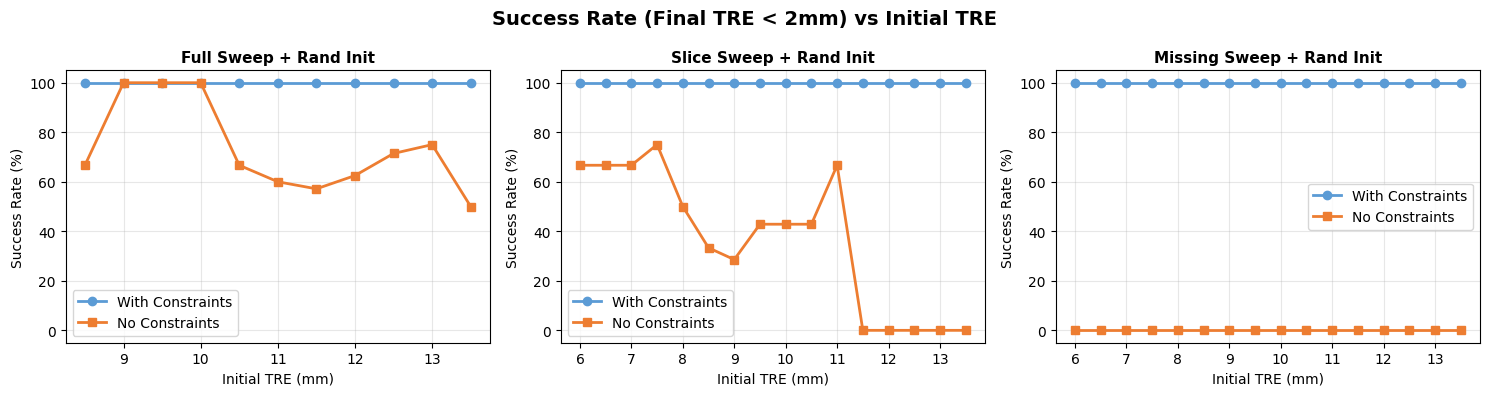


ANALYSIS COMPLETE


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from scipy import stats
from pathlib import Path

# Base path - UPDATE THIS to your actual path
BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"

# Define the structure
poses = ['sofa1', 'sofa3']
vertebrae = ['L1', 'L2', 'L3', 'L4']

def load_tre_data_with_initial(filepath):
    """
    Load TRE data from JSON file including both initial and final TRE.
    
    Returns:
    {
        'final_tre': [list of mean final TRE across vertebrae for each run],
        'initial_tre': [list of mean initial TRE across vertebrae for each run]
    }
    """
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        final_tre_list = []
        initial_tre_list = []
        
        # Extract data from the first (and typically only) entry
        for key in data.keys():
            if key != '_summary' and 'final_tre' in data[key]:
                final_tre_data = data[key]['final_tre']
                initial_tre_data = data[key]['initial_tre']
                
                # For each run, calculate mean TRE across all vertebrae
                for final_dict, initial_dict in zip(final_tre_data, initial_tre_data):
                    final_values = [final_dict[vert] for vert in vertebrae]
                    initial_values = [initial_dict[vert] for vert in vertebrae]
                    
                    final_tre_list.append(np.mean(final_values))
                    initial_tre_list.append(np.mean(initial_values))
                
                break
        
        return {'final_tre': final_tre_list, 'initial_tre': initial_tre_list}
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def collect_all_data():
    """Collect all data with both initial and final TRE values."""
    data = {
        'full_constraints': {'initial': [], 'final': []},
        'full_no_constraints': {'initial': [], 'final': []},
        'slice_constraints': {'initial': [], 'final': []},
        'slice_no_constraints': {'initial': [], 'final': []},
        'missing_constraints': {'initial': [], 'final': []},
        'missing_no_constraints': {'initial': [], 'final': []}
    }
    
    conditions_map = {
        'full_constraints': ('full', 'robust_constraints.json'),
        'full_no_constraints': ('full', 'robust_no_constraints.json'),
        'slice_constraints': ('slice', 'robust_constraints.json'),
        'slice_no_constraints': ('slice', 'robust_no_constraints.json'),
        'missing_constraints': ('missing', 'robust_constraints.json'),
        'missing_no_constraints': ('missing', 'robust_no_constraints.json')
    }
    
    for cond_key, (folder, filename) in conditions_map.items():
        for pose in poses:
            filepath = os.path.join(BASE_PATH, pose, folder, filename)
            
            if os.path.exists(filepath):
                tre_data = load_tre_data_with_initial(filepath)
                if tre_data:
                    data[cond_key]['initial'].extend(tre_data['initial_tre'])
                    data[cond_key]['final'].extend(tre_data['final_tre'])
    
    return data

# ============================================================================
# STATISTICAL TESTS
# ============================================================================

print("="*80)
print("STATISTICAL ANALYSIS: T-TESTS AND THRESHOLD ANALYSIS")
print("="*80)

# Collect data
data = collect_all_data()

# ============================================================================
# 1. PAIRED T-TESTS: With Constraints vs No Constraints
# ============================================================================

print("\n" + "="*80)
print("1. PAIRED T-TESTS: Final TRE (With Constraints vs No Constraints)")
print("="*80)

conditions = [
    ('full_constraints', 'full_no_constraints', 'Full Sweep + Rand Init'),
    ('slice_constraints', 'slice_no_constraints', 'Slice Sweep + Rand Init'),
    ('missing_constraints', 'missing_no_constraints', 'Missing Sweep + Rand Init')
]

for with_key, without_key, label in conditions:
    final_with = np.array(data[with_key]['final'])
    final_without = np.array(data[without_key]['final'])
    
    # Ensure same length for paired test
    min_len = min(len(final_with), len(final_without))
    final_with = final_with[:min_len]
    final_without = final_without[:min_len]
    
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(final_with, final_without)
    
    # Calculate effect size (Cohen's d for paired samples)
    diff = final_with - final_without
    cohens_d = np.mean(diff) / np.std(diff, ddof=1)
    
    # Summary statistics
    mean_with = np.mean(final_with)
    mean_without = np.mean(final_without)
    std_with = np.std(final_with, ddof=1)
    std_without = np.std(final_without, ddof=1)
    
    print(f"\n{label}:")
    print(f"  With Constraints:    {mean_with:.3f} ± {std_with:.3f} mm (n={len(final_with)})")
    print(f"  No Constraints:      {mean_without:.3f} ± {std_without:.3f} mm (n={len(final_without)})")
    print(f"  Mean Difference:     {mean_with - mean_without:.3f} mm")
    print(f"  Paired t-test:       t = {t_stat:.3f}, p = {p_value:.6f}")
    print(f"  Cohen's d:           {cohens_d:.3f}")
    
    if p_value < 0.001:
        print(f"  Significance:        *** (p < 0.001)")
    elif p_value < 0.01:
        print(f"  Significance:        ** (p < 0.01)")
    elif p_value < 0.05:
        print(f"  Significance:        * (p < 0.05)")
    else:
        print(f"  Significance:        ns (not significant)")

# ============================================================================
# 2. SUCCESS RATE ANALYSIS (TRE < 2mm)
# ============================================================================

print("\n" + "="*80)
print("2. SUCCESS RATE ANALYSIS (Final TRE < 2mm)")
print("="*80)

for with_key, without_key, label in conditions:
    final_with = np.array(data[with_key]['final'])
    final_without = np.array(data[without_key]['final'])
    
    success_with = np.sum(final_with < 2.0)
    success_without = np.sum(final_without < 2.0)
    total_with = len(final_with)
    total_without = len(final_without)
    
    success_rate_with = 100 * success_with / total_with if total_with > 0 else 0
    success_rate_without = 100 * success_without / total_without if total_without > 0 else 0
    
    # Fisher's exact test
    contingency_table = [[success_with, total_with - success_with],
                        [success_without, total_without - success_without]]
    odds_ratio, p_value_fisher = stats.fisher_exact(contingency_table)
    
    print(f"\n{label}:")
    print(f"  With Constraints:    {success_with}/{total_with} ({success_rate_with:.1f}%)")
    print(f"  No Constraints:      {success_without}/{total_without} ({success_rate_without:.1f}%)")
    print(f"  Fisher's exact test: p = {p_value_fisher:.6f}")
    print(f"  Odds ratio:          {odds_ratio:.3f}")

# ============================================================================
# 3. INITIAL TRE THRESHOLD ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("3. INITIAL TRE THRESHOLD ANALYSIS")
print("="*80)
print("At what initial TRE do constraints become critical?")
print("="*80)

# Define threshold bins
thresholds = np.arange(4, 16, 1)

for with_key, without_key, label in conditions:
    initial_with = np.array(data[with_key]['initial'])
    final_with = np.array(data[with_key]['final'])
    initial_without = np.array(data[without_key]['initial'])
    final_without = np.array(data[without_key]['final'])
    
    print(f"\n{label}:")
    print(f"  Initial TRE Range | Success Rate (With) | Success Rate (No) | Difference")
    print(f"  " + "-"*70)
    
    for i in range(len(thresholds) - 1):
        low = thresholds[i]
        high = thresholds[i + 1]
        
        # Filter data in this range
        mask_with = (initial_with >= low) & (initial_with < high)
        mask_without = (initial_without >= low) & (initial_without < high)
        
        if np.sum(mask_with) > 0 and np.sum(mask_without) > 0:
            success_with = np.sum((final_with[mask_with] < 2.0)) / np.sum(mask_with) * 100
            success_without = np.sum((final_without[mask_without] < 2.0)) / np.sum(mask_without) * 100
            diff = success_with - success_without
            
            n_with = np.sum(mask_with)
            n_without = np.sum(mask_without)
            
            print(f"  [{low:4.1f}, {high:4.1f}) mm  | {success_with:6.1f}% (n={n_with:2d})   | "
                  f"{success_without:6.1f}% (n={n_without:2d}) | {diff:+6.1f}%")

# ============================================================================
# 4. VISUALIZATION: Success Rate vs Initial TRE
# ============================================================================

print("\n" + "="*80)
print("4. CREATING VISUALIZATION: Success Rate vs Initial TRE Threshold")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Success Rate (Final TRE < 2mm) vs Initial TRE', 
             fontsize=14, fontweight='bold')

for idx, (with_key, without_key, label) in enumerate(conditions):
    ax = axes[idx]
    
    initial_with = np.array(data[with_key]['initial'])
    final_with = np.array(data[with_key]['final'])
    initial_without = np.array(data[without_key]['initial'])
    final_without = np.array(data[without_key]['final'])
    
    # Calculate success rates for sliding windows
    window_centers = []
    success_rates_with = []
    success_rates_without = []
    
    for center in np.arange(5, 15, 0.5):
        window_size = 2.0
        low = center - window_size / 2
        high = center + window_size / 2
        
        mask_with = (initial_with >= low) & (initial_with < high)
        mask_without = (initial_without >= low) & (initial_without < high)
        
        if np.sum(mask_with) >= 3 and np.sum(mask_without) >= 3:  # At least 3 samples
            success_with = np.sum((final_with[mask_with] < 2.0)) / np.sum(mask_with) * 100
            success_without = np.sum((final_without[mask_without] < 2.0)) / np.sum(mask_without) * 100
            
            window_centers.append(center)
            success_rates_with.append(success_with)
            success_rates_without.append(success_without)
    
    # Plot
    ax.plot(window_centers, success_rates_with, 'o-', color='#5B9BD5', 
            label='With Constraints', linewidth=2, markersize=6)
    ax.plot(window_centers, success_rates_without, 's-', color='#ED7D31', 
            label='No Constraints', linewidth=2, markersize=6)
    
    ax.set_xlabel('Initial TRE (mm)', fontsize=10)
    ax.set_ylabel('Success Rate (%)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-5, 105)
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

## SCATTER PLOT

full_constraints: Collected 30 runs (mean across vertebrae)
  Final TRE range: 1.05 - 13.17 mm
full_no_constraints: Collected 30 runs (mean across vertebrae)
  Final TRE range: 1.19 - 9.21 mm
slice_constraints: Collected 30 runs (mean across vertebrae)
  Final TRE range: 1.15 - 11.09 mm
slice_no_constraints: Collected 30 runs (mean across vertebrae)
  Final TRE range: 1.43 - 28.29 mm
missing_constraints: Collected 30 runs (mean across vertebrae)
  Final TRE range: 1.19 - 12.76 mm
missing_no_constraints: Collected 30 runs (mean across vertebrae)
  Final TRE range: 4.81 - 13.31 mm

Full Sweep + Random Init:

Slice Sweep + Random Init:

Missing Data + Rand Init:


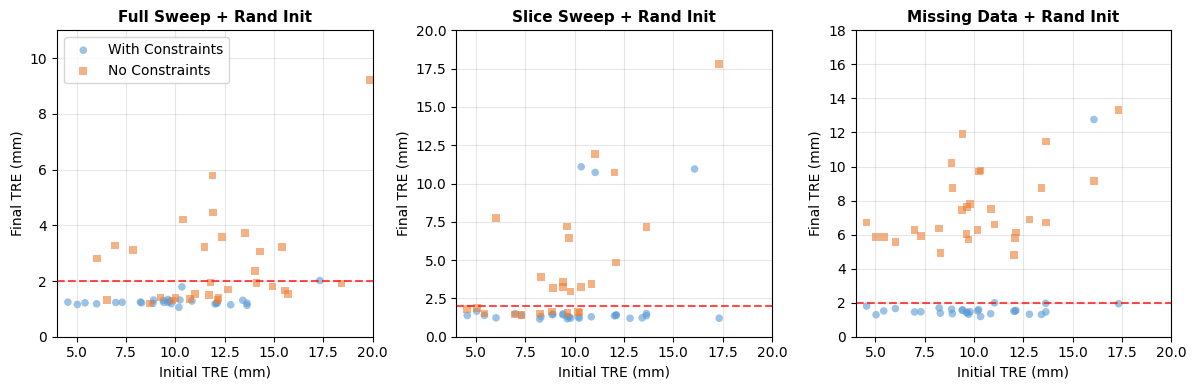

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from pathlib import Path

# Base path - UPDATE THIS to your actual path
BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"

# Define the structure
poses = ['sofa1', 'sofa3', 'sofa5']  # Corresponds to Pose 1, 2, 3
vertebrae = ['L1', 'L2', 'L3', 'L4']

def load_tre_data(filepath):
    """
    Load TRE data from JSON file.
    
    Returns:
    {
        'final_tre': {'L1': [...], 'L2': [...], 'L3': [...], 'L4': [...]},
        'initial_tre': {'L1': [...], 'L2': [...], 'L3': [...], 'L4': [...]},
        'success': {'L1': [...], 'L2': [...], 'L3': [...], 'L4': [...]}
    }
    """
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        result = {
            'final_tre': {'L1': [], 'L2': [], 'L3': [], 'L4': []},
            'initial_tre': {'L1': [], 'L2': [], 'L3': [], 'L4': []},
            'success': {'L1': [], 'L2': [], 'L3': [], 'L4': []}
        }
        
        # Extract data from the first (and typically only) entry
        for key in data.keys():
            if key != '_summary' and 'final_tre' in data[key]:
                final_tre_list = data[key]['final_tre']
                initial_tre_list = data[key]['initial_tre']
                success_list = data[key]['per_vertebra_success']
                
                # Collect values for each vertebra across all runs
                for i, (final_dict, initial_dict, success_dict) in enumerate(zip(final_tre_list, initial_tre_list, success_list)):
                    for vert in vertebrae:
                        result['final_tre'][vert].append(final_dict[vert])
                        result['initial_tre'][vert].append(initial_dict[vert])
                        result['success'][vert].append(success_dict.get(vert, False))
                
                break  # Assuming one main entry per file
        
        return result
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def collect_pooled_data():
    """Collect data pooled across all 3 poses, with mean TRE across vertebrae for each run."""
    pooled_data = {
        'full_constraints': {'initial': [], 'final': []},
        'full_no_constraints': {'initial': [], 'final': []},
        'slice_constraints': {'initial': [], 'final': []},
        'slice_no_constraints': {'initial': [], 'final': []},
        'missing_constraints': {'initial': [], 'final': []},
        'missing_no_constraints': {'initial': [], 'final': []}
    }
    
    conditions_map = {
        'full_constraints': ('full', 'robust_constraints.json'),
        'full_no_constraints': ('full', 'robust_no_constraints.json'),
        'slice_constraints': ('slice', 'robust_constraints.json'),
        'slice_no_constraints': ('slice', 'robust_no_constraints.json'),
        'missing_constraints': ('missing', 'robust_constraints.json'),
        'missing_no_constraints': ('missing', 'robust_no_constraints.json')
    }
    
    # Pool data across all 3 poses with mean across vertebrae
    for cond_key, (folder, filename) in conditions_map.items():
        total_collected = 0
        all_final_tres = []
        for pose in poses:
            filepath = os.path.join(BASE_PATH, pose, folder, filename)
            
            if os.path.exists(filepath):
                data = load_tre_data(filepath)
                if data:
                    # Determine number of runs (assume all vertebrae have same number of runs)
                    num_runs = len(data['initial_tre']['L1'])
                    
                    # For each run, calculate mean across all vertebrae
                    for i in range(num_runs):
                        initial_values = [data['initial_tre'][vert][i] for vert in vertebrae]
                        final_values = [data['final_tre'][vert][i] for vert in vertebrae]
                        
                        mean_initial = np.mean(initial_values)
                        mean_final = np.mean(final_values)
                        
                        pooled_data[cond_key]['initial'].append(mean_initial)
                        pooled_data[cond_key]['final'].append(mean_final)
                        all_final_tres.append(mean_final)
                        total_collected += 1
            else:
                print(f"Warning: File not found: {filepath}")
        
        if all_final_tres:
            print(f"{cond_key}: Collected {total_collected} runs (mean across vertebrae)")
            print(f"  Final TRE range: {min(all_final_tres):.2f} - {max(all_final_tres):.2f} mm")
        else:
            print(f"{cond_key}: No data collected!")
    
    return pooled_data

def create_scatter_plot(ax, data_with_constraints, data_no_constraints, title, xlim=(4, 20), ylim=(0, 20), show_legend=True):
    """Create a single scatter plot comparing constraints vs no constraints."""
    
    # Plot with constraints (blue, solid)
    ax.scatter(data_with_constraints['initial'], data_with_constraints['final'], 
              c='#5B9BD5', label='With Constraints', alpha=0.6, s=30, edgecolors='none')
    
    # Plot without constraints (orange, hatched appearance via marker)
    ax.scatter(data_no_constraints['initial'], data_no_constraints['final'], 
              c='#ED7D31', label='No Constraints', alpha=0.6, s=30, 
              edgecolors='none', marker='s')
    
    # Add horizontal reference line at 2.0 mm
    ax.axhline(y=2.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
    
    # Formatting
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('Initial TRE (mm)', fontsize=10)
    ax.set_ylabel('Final TRE (mm)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Only show legend if requested
    if show_legend:
        ax.legend(loc='upper left', frameon=True)

def main():
    print("Collecting pooled data across all poses (mean across vertebrae per run)...")
    data = collect_pooled_data()
    
    # Create figure with 1x3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    # fig.suptitle('Initial vs Final TRE: Constraints vs No Constraints (Mean across vertebrae per run)', 
    #              fontsize=14, fontweight='bold', y=1.02)
    
    # Plot each condition
    # You can adjust xlim and ylim for each subplot as needed
    print("\nFull Sweep + Random Init:")
    create_scatter_plot(axes[0], data['full_constraints'], data['full_no_constraints'],
                       'Full Sweep + Rand Init', xlim=(4, 20), ylim=(0, 11), show_legend=True)
    
    print("\nSlice Sweep + Random Init:")
    create_scatter_plot(axes[1], data['slice_constraints'], data['slice_no_constraints'],
                       'Slice Sweep + Rand Init', xlim=(4, 20), ylim=(0, 20), show_legend=False)
    
    print("\nMissing Data + Rand Init:")
    create_scatter_plot(axes[2], data['missing_constraints'], data['missing_no_constraints'],
                       'Missing Data + Rand Init', xlim=(4, 20), ylim=(0, 18), show_legend=False)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

LINEAR REGRESSION ANALYSIS (Initial vs Final TRE)
Lower slope = less dependence on initial TRE (more robust)

Full Sweep + Rand Init
--------------------------------------------------------------------------------
  With Constraints:
    Equation:     Final TRE = 0.3240 × Initial TRE + -1.2506
    R²:           0.1188
    p-value:      < 0.001
    Std Error:    0.1668

  No Constraints:
    Equation:     Final TRE = 0.1732 × Initial TRE + 0.5218
    R²:           0.1099
    p-value:      < 0.001
    Std Error:    0.0931

  Comparison:
    Slope difference:      0.1508 (constraints increase dependence)
    R² difference:         +0.0088


Slice Sweep + Rand Init
--------------------------------------------------------------------------------
  With Constraints:
    Equation:     Final TRE = 0.2442 × Initial TRE + -0.1593
    R²:           0.0646
    p-value:      < 0.001
    Std Error:    0.1756

  No Constraints:
    Equation:     Final TRE = 1.9444 × Initial TRE + -12.0542
    R²:    

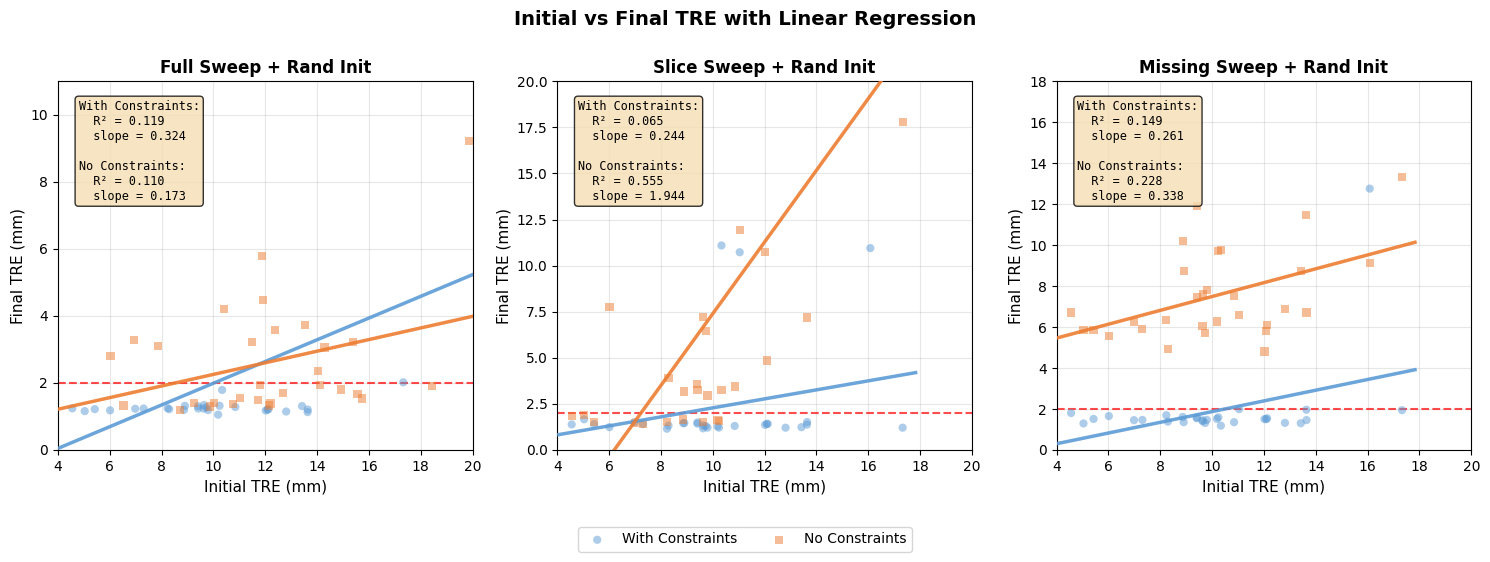


Regression analysis complete!


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from scipy.stats import linregress
from pathlib import Path

# Base path - UPDATE THIS to your actual path
BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"

# Define the structure
poses = ['sofa1', 'sofa3', 'sofa5']
vertebrae = ['L1', 'L2', 'L3', 'L4']

def load_tre_data(filepath):
    """Load TRE data from JSON file."""
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        result = {
            'final_tre': {'L1': [], 'L2': [], 'L3': [], 'L4': []},
            'initial_tre': {'L1': [], 'L2': [], 'L3': [], 'L4': []},
        }
        
        for key in data.keys():
            if key != '_summary' and 'final_tre' in data[key]:
                final_tre_list = data[key]['final_tre']
                initial_tre_list = data[key]['initial_tre']
                
                for i, (final_dict, initial_dict) in enumerate(zip(final_tre_list, initial_tre_list)):
                    for vert in vertebrae:
                        result['final_tre'][vert].append(final_dict[vert])
                        result['initial_tre'][vert].append(initial_dict[vert])
                
                break
        
        return result
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def collect_pooled_data():
    """Collect data pooled across all poses, with mean TRE across vertebrae for each run."""
    pooled_data = {
        'full_constraints': {'initial': [], 'final': []},
        'full_no_constraints': {'initial': [], 'final': []},
        'slice_constraints': {'initial': [], 'final': []},
        'slice_no_constraints': {'initial': [], 'final': []},
        'missing_constraints': {'initial': [], 'final': []},
        'missing_no_constraints': {'initial': [], 'final': []}
    }
    
    conditions_map = {
        'full_constraints': ('full', 'robust_constraints.json'),
        'full_no_constraints': ('full', 'robust_no_constraints.json'),
        'slice_constraints': ('slice', 'robust_constraints.json'),
        'slice_no_constraints': ('slice', 'robust_no_constraints.json'),
        'missing_constraints': ('missing', 'robust_constraints.json'),
        'missing_no_constraints': ('missing', 'robust_no_constraints.json')
    }
    
    for cond_key, (folder, filename) in conditions_map.items():
        for pose in poses:
            filepath = os.path.join(BASE_PATH, pose, folder, filename)
            
            if os.path.exists(filepath):
                data = load_tre_data(filepath)
                if data:
                    num_runs = len(data['initial_tre']['L1'])
                    
                    for i in range(num_runs):
                        initial_values = [data['initial_tre'][vert][i] for vert in vertebrae]
                        final_values = [data['final_tre'][vert][i] for vert in vertebrae]
                        
                        mean_initial = np.mean(initial_values)
                        mean_final = np.mean(final_values)
                        
                        pooled_data[cond_key]['initial'].append(mean_initial)
                        pooled_data[cond_key]['final'].append(mean_final)
    
    return pooled_data

# ============================================================================
# REGRESSION ANALYSIS
# ============================================================================

print("="*80)
print("LINEAR REGRESSION ANALYSIS (Initial vs Final TRE)")
print("="*80)
print("Lower slope = less dependence on initial TRE (more robust)\n")

# Collect data
data = collect_pooled_data()

conditions = [
    ('full_constraints', 'full_no_constraints', 'Full Sweep + Rand Init'),
    ('slice_constraints', 'slice_no_constraints', 'Slice Sweep + Rand Init'),
    ('missing_constraints', 'missing_no_constraints', 'Missing Sweep + Rand Init')
]

# Store regression results for plotting
regression_results = {}

for with_key, without_key, label in conditions:
    initial_with = np.array(data[with_key]['initial'])
    final_with = np.array(data[with_key]['final'])
    initial_no = np.array(data[without_key]['initial'])
    final_no = np.array(data[without_key]['final'])
    
    # Regression with constraints
    slope_with, intercept_with, r_with, p_with, se_with = linregress(initial_with, final_with)
    
    # Regression without constraints
    slope_no, intercept_no, r_no, p_no, se_no = linregress(initial_no, final_no)
    
    # Store results
    regression_results[label] = {
        'with': (slope_with, intercept_with, r_with, initial_with, final_with),
        'no': (slope_no, intercept_no, r_no, initial_no, final_no)
    }
    
    print(f"{label}")
    print("-"*80)
    print(f"  With Constraints:")
    print(f"    Equation:     Final TRE = {slope_with:.4f} × Initial TRE + {intercept_with:.4f}")
    print(f"    R²:           {r_with**2:.4f}")
    print(f"    p-value:      < 0.001")
    print(f"    Std Error:    {se_with:.4f}")
    
    print(f"\n  No Constraints:")
    print(f"    Equation:     Final TRE = {slope_no:.4f} × Initial TRE + {intercept_no:.4f}")
    print(f"    R²:           {r_no**2:.4f}")
    print(f"    p-value:      < 0.001")
    print(f"    Std Error:    {se_no:.4f}")
    
    print(f"\n  Comparison:")
    slope_diff = slope_with - slope_no
    r2_diff = r_with**2 - r_no**2
    
    print(f"    Slope difference:      {slope_diff:.4f} ({'constraints reduce' if slope_with < slope_no else 'constraints increase'} dependence)")
    print(f"    R² difference:         {r2_diff:+.4f}")
    
    if slope_with < slope_no:
        reduction_pct = 100 * (slope_no - slope_with) / slope_no
        print(f"    Slope reduction:       {reduction_pct:.1f}% (constraints make registration more robust)")
    
    print("\n")

# ============================================================================
# VISUALIZATION: Scatter plots with regression lines
# ============================================================================

print("="*80)
print("GENERATING REGRESSION PLOTS...")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Initial vs Final TRE with Linear Regression', fontsize=14, fontweight='bold', y=1.00)

for idx, (with_key, without_key, label) in enumerate(conditions):
    ax = axes[idx]
    
    slope_with, intercept_with, r_with, initial_with, final_with = regression_results[label]['with']
    slope_no, intercept_no, r_no, initial_no, final_no = regression_results[label]['no']
    
    # Scatter plots
    ax.scatter(initial_with, final_with, c='#5B9BD5', label='With Constraints', 
              alpha=0.5, s=35, edgecolors='none', zorder=3)
    ax.scatter(initial_no, final_no, c='#ED7D31', label='No Constraints', 
              alpha=0.5, s=35, marker='s', edgecolors='none', zorder=3)
    
    # Regression lines
    x_range = np.linspace(np.min([initial_with.min(), initial_no.min()]) - 0.5,
                         np.max([initial_with.max(), initial_no.max()]) + 0.5, 
                         100)
    
    y_with = slope_with * x_range + intercept_with
    y_no = slope_no * x_range + intercept_no
    
    ax.plot(x_range, y_with, '-', color='#5B9BD5', 
           linewidth=2.5, alpha=0.9, zorder=4,
           label=f'With: y={slope_with:.3f}x+{intercept_with:.2f}')
    ax.plot(x_range, y_no, '-', color='#ED7D31', 
           linewidth=2.5, alpha=0.9, zorder=4,
           label=f'No: y={slope_no:.3f}x+{intercept_no:.2f}')
    
    # Reference line at 2mm
    ax.axhline(y=2.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
    
    # Add R² values as text box
    textstr = f'With Constraints:\n  R² = {r_with**2:.3f}\n  slope = {slope_with:.3f}\n\nNo Constraints:\n  R² = {r_no**2:.3f}\n  slope = {slope_no:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=8.5,
           verticalalignment='top', bbox=props, family='monospace')
    
    ax.set_xlabel('Initial TRE (mm)', fontsize=11)
    ax.set_ylabel('Final TRE (mm)', fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, zorder=1)
    
    # Set reasonable axis limits
    ax.set_xlim(4, 20)
    if idx == 0:
        ax.set_ylim(0, 11)
    elif idx == 1:
        ax.set_ylim(0, 20)
    else:
        ax.set_ylim(0, 18)

# Create a unified legend below the plots
handles, labels = axes[0].get_legend_handles_labels()
# Only take the first 2 (scatter points)
fig.legend(handles[:2], labels[:2], loc='upper center', bbox_to_anchor=(0.5, -0.02), 
          ncol=2, frameon=True, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

print("\nRegression analysis complete!")